# Classification Models Training for Attrition Prediction
## Importing Dependencies

In [69]:
import sys
import os
import warnings
import joblib

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("..", "scripts", "utils")))

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve, recall_score, precision_score, f1_score, auc

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [2]:
DATA_PATH = os.path.join("..", "data", "processed", "hr_employee_attrition.csv")

# Setting parameters
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

mpl.rc("axes", labelsize=14)
mpl.rc("xtick", labelsize=12)
mpl.rc("ytick", labelsize=12)

plt.style.use("ggplot")
sns.set_style("darkgrid", {"grid.color": ".8"})

## Loading Data

In [3]:
df = pd.read_csv(DATA_PATH)
df.head()

,OverTime,BusinessTravel,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Age,DailyRate,DistanceFromHome,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyRate,NumCompaniesWorked,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,NEW_IncomeStability,NEW_OvertimeImpact,NEW_AttritionRiskScore,NEW_FirstJob,NEW_FrequentTraveler,NEW_MarriedWithHighWorkload,Attrition
0,-1.59,-0.16,-1.37,1.52,1.19,-0.35,-0.68,-0.24,-0.31,-1.22,-0.19,-0.46,-0.27,-0.33,-0.24,-0.50,1.87,-0.24,-0.92,1.46,0.45,0.74,-1.51,-0.66,1.38,0.38,-0.06,1.15,0.73,2.13,-1.58,-0.93,-0.14,-2.17,-2.49,0.18,-0.06,-0.68,0.25,-0.54,2.32,0.94,-0.39,-0.48,-0.38,1
1,0.63,1.72,0.73,-0.66,1.19,-0.35,-0.68,-0.24,-0.31,0.82,-0.19,-0.46,-0.27,-0.33,-0.24,2.01,-0.53,-0.24,1.09,-0.69,1.32,-1.30,0.26,0.25,-0.24,-1.03,-0.06,-0.66,1.49,-0.68,1.19,0.24,0.16,0.16,0.34,0.83,0.76,-0.37,0.81,-0.83,-0.57,-0.21,-0.39,2.08,-0.38,0
2,-1.59,-0.16,0.73,-0.66,-0.84,-0.35,-0.68,4.11,-0.31,0.82,-0.19,2.16,-0.27,-0.33,-0.24,-0.50,-0.53,-0.24,-0.92,1.46,0.01,1.41,-1.03,1.17,1.28,-1.03,-0.96,0.25,-1.67,1.32,-0.66,-0.93,-0.32,0.16,0.34,-1.62,-1.17,-0.68,-1.16,0.71,1.60,0.36,-0.39,-0.48,-0.38,1
3,-1.59,1.72,0.73,-0.66,1.19,-0.35,-0.68,-0.24,-0.31,-1.22,-0.19,-0.46,-0.27,-0.33,-0.24,2.01,-0.53,-0.24,1.09,-0.69,-0.43,1.46,-0.70,1.17,-0.49,0.38,-0.96,0.25,1.24,-0.68,0.27,-0.93,-0.14,0.16,0.34,0.54,0.76,0.25,-1.16,-1.07,1.60,0.36,-0.39,2.08,2.63,0
4,0.63,-0.16,0.73,-0.66,-0.84,-0.35,1.47,-0.24,-0.31,0.82,-0.19,2.16,-0.27,-0.33,-0.24,-0.50,-0.53,-0.24,1.09,-0.69,-1.09,-0.52,-1.03,-1.58,-1.27,0.38,-0.96,-0.66,0.33,2.53,1.19,0.24,-0.52,0.16,0.34,-1.04,-0.62,-0.06,-0.60,-0.82,-0.57,-0.21,-0.39,-0.48,-0.38,0


In [4]:
X, y = df.drop(columns=["Attrition"]), df["Attrition"]  
X.shape, y.shape

((1470, 45), (1470,))

In [5]:
# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [6]:
len(X_train), len(X_test), len(y_train), len(y_test)

(1176, 294, 1176, 294)

In [7]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)  # 0 - No, 1 - Yes

(Attrition
 0   0.84
 1   0.16
 Name: proportion, dtype: float64,
 Attrition
 0   0.84
 1   0.16
 Name: proportion, dtype: float64)

## Model Selection

In [8]:
models = [
    ("Logistic Regression", LogisticRegression(random_state=42, max_iter=500)),
    ("Support Vector Machines", SVC(probability=True, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsClassifier()),
    ("Random Forest", RandomForestClassifier(max_depth=5, random_state=42)),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=42)),
    ("AdaBoost", AdaBoostClassifier(random_state=42)),
    ("XGBoost", XGBClassifier(eval_metric="logloss", random_state=42)),
    ("LightGBM", LGBMClassifier(random_state=42, verbose=-1)),
    ("CatBoost", CatBoostClassifier(verbose=0, random_state=42))
]

In [ ]:
results = []

for name, model in models:
    print(f"Training {name}...")
    
    cv_scores = cross_val_score(model, X_train, y_train, scoring="f1_macro", cv=5)
    cv_f1 = cv_scores.mean()
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    test_accuracy = accuracy_score(y_test, y_pred)  # accuracy metric for highly imbalanced data can be misleading
    test_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    test_recall = recall_score(y_test, y_pred, average="weighted")
    test_f1 = f1_score(y_test, y_pred, average="weighted")
    
    results.append({
        "Model": name,
        "CV F1-macro": cv_f1,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1
    })

results_df = pd.DataFrame(results).sort_values(by="CV F1-macro", ascending=False)
results_df

Training Logistic Regression...
Training Support Vector Machines...
Training K-Nearest Neighbors...
Training Random Forest...
Training Gradient Boosting...
Training AdaBoost...
Training XGBoost...
Training LightGBM...
Training CatBoost...


,Model,CV F1-macro,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.75,0.86,0.84,0.86,0.84
5,AdaBoost,0.70,0.83,0.79,0.83,0.80
4,Gradient Boosting,0.68,0.86,0.83,0.86,0.83
6,XGBoost,0.68,0.88,0.87,0.88,0.86
7,LightGBM,0.68,0.86,0.83,0.86,0.83
1,Support Vector Machines,0.68,0.85,0.82,0.85,0.81
8,CatBoost,0.67,0.85,0.83,0.85,0.82
2,K-Nearest Neighbors,0.58,0.85,0.81,0.85,0.81
3,Random Forest,0.57,0.84,0.81,0.84,0.79


## Training and Evaluating `LogisticRegression` Model 

#### Compute Class Weights for Unbalanced Data (Attrition)

In [60]:
from sklearn.utils.class_weight import compute_class_weight

class_names = np.array([0, 1])

class_weights = compute_class_weight(class_weight="balanced", classes=class_names, y=y_train) 
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
print("Class weights:", class_weight_dict)

Class weights: {0: 0.5963488843813387, 1: 3.094736842105263}


In [ ]:
model = LogisticRegression(max_iter=500, class_weight=class_weights, random_state=42)

In [ ]:
from scipy.stats import loguniform

param_dist = {
    "penalty": ["l1", "l2", "elasticnet", None],  
    "C": loguniform(1e-4, 1e2), 
    "solver": ["liblinear", "saga"], 
    "l1_ratio": loguniform(0.01, 1) 
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=100,
    scoring="f1_macro",
    cv=4,  
    verbose=1,
    random_state=42,
    n_jobs=-1, 
)

In [51]:
random_search.fit(X_train, y_train)

print("Best parameters found: ", random_search.best_params_)
print("Best accuracy score: ", random_search.best_score_)

Fitting 4 folds for each of 100 candidates, totalling 400 fits
Best parameters found:  {'C': 0.054502936945582565, 'l1_ratio': 0.3718364180573207, 'penalty': 'elasticnet', 'solver': 'saga'}
Best accuracy score:  0.6857780089406025


In [55]:
best_model = LogisticRegression(**random_search.best_params_, class_weight=class_weights, random_state=42)  
best_model.fit(X_train, y_train)

LogisticRegression(C=0.054502936945582565,
                   class_weight={0: 0.5963488843813387, 1: 3.094736842105263},
                   l1_ratio=0.3718364180573207, penalty='elasticnet',
                   random_state=42, solver='saga')

In [90]:
joblib.dump(random_search.best_params_, os.path.join("..", "models", "best_logistic_regression_params.joblib"))
joblib.dump(best_model, os.path.join("..", "models", "best_logistic_regression_model.joblib"))

['..\\models\\best_logistic_regression_model.joblib']

## Model Evaluation

In [ ]:
class_names = ["No", "Yes"]

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

          No       0.93      0.81      0.87       247
         Yes       0.40      0.66      0.50        47

    accuracy                           0.79       294
   macro avg       0.66      0.74      0.68       294
weighted avg       0.84      0.79      0.81       294



### Confusion Matrix

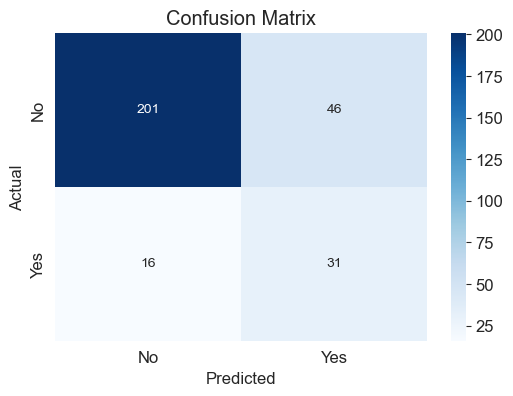

In [57]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### ROC curve and AUC score

In [67]:
y_probs = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

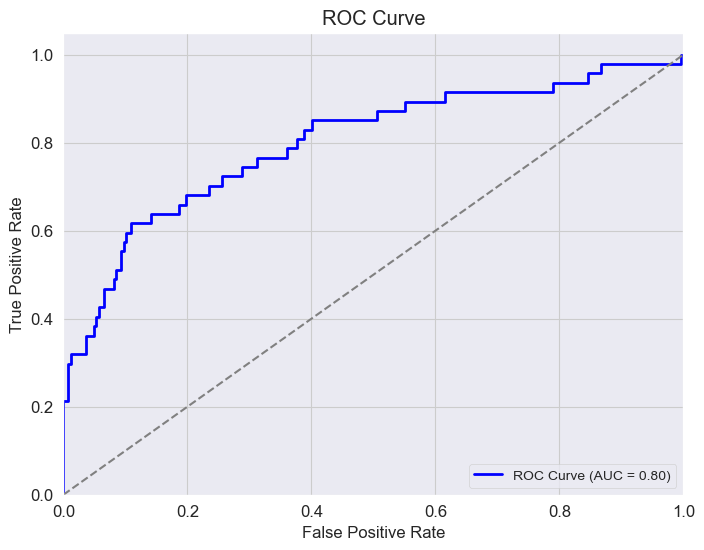

In [68]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
auc_score = roc_auc_score(y_test, y_probs)
print(f"ROC AUC Score: {auc_score:.2f}")

ROC AUC Score: 0.80
